### PARAM FIT

In [2]:
# %%
import numpy as np
from matplotlib import pyplot as plt
import csv

# %matplotlib inline

import xarray as xr
import lib_ecofun as lef

from scipy.optimize import curve_fit, minimize, dual_annealing, basinhopping, brute, differential_evolution, shgo, direct


In [104]:
# %%
year_ini = 2000
params = lef.default_params.copy()

verbose = False

public_investment = False

params['r_inv_state'] = 0.015
arr = np.concatenate([np.linspace(0., 0.7, 20), np.linspace(0.7, 0.7, 80)])
mu_scen = xr.DataArray(arr, dims = ('year'), coords = {'year': np.arange(year_ini, year_ini + 100)})

obs_weights = None

result_dict = {}

In [17]:
params

{'growth': 0.01,
 'eps': 1,
 'a': 1,
 'b': 1,
 'gamma_f': 0.5,
 'gamma_g': 0.5,
 'eta_g': 0.2,
 'eta_f': 0.2,
 'h_g': 0.5,
 'h_f': 0.5,
 'r_inv': 0.1,
 'beta_0': 0.2,
 'delta_sig': 0.5,
 'delta_g': 0.01,
 'delta_f': 0.01,
 'f_heavy': 0.1,
 'r_inv_state': 0.015}

In [109]:
params['a'] = 2.3
params['b'] = 1.4

In [110]:
params_prime = params.copy()

params_prime['a'] = lef.a_prime(year_ini, a = params['a'])
params_prime['b'] = lef.a_prime(year_ini, a = params['b'])

In [111]:
params_prime

{'growth': 0.01,
 'eps': 1,
 'a': 0.7061236460320618,
 'b': 0.4298143932369072,
 'gamma_f': 0.5,
 'gamma_g': 0.5,
 'eta_g': 0.2,
 'eta_f': 0.2,
 'h_g': 0.5,
 'h_f': 0.5,
 'r_inv': 0.1,
 'beta_0': 0.2,
 'delta_sig': 0.5,
 'delta_g': 0.01,
 'delta_f': 0.01,
 'f_heavy': 0.1,
 'r_inv_state': 0.015}

In [69]:
params_prime_range = {
 'growth': (0.01, 0.04),
 'a': (0.6, 1.1),
 'b': (0.3, 0.8),
 'gamma_f': (0.1, 0.7),
 'gamma_g': (0.1, 0.7),
 'eta_g': (0.2, 0.95),
 'eta_f': (0.2, 0.95),
 'r_inv': (0.05, 0.5),
 'beta_0': (-0.5, 0.5)}

In [70]:
# parnames = ['growth', 'beta_0', 'r_inv', 'a', 'b', 'eta_g', 'gamma_g']
parnames = ['growth', 'beta_0', 'r_inv', 'eta_f', 'gamma_f', 'eta_g', 'gamma_g']

In [71]:
bounds = [params_prime_range[par] for par in parnames]

In [112]:
inicond = lef.inicond_yr(year_ini, params_prime, adimensional = True, fcu = lef.fossil_capacity_util)

In [113]:
inicond

{'Y_ini': 1.0,
 'Eg_ini': 0.07825325742181562,
 'Ef_ini': 0.9217467425781845,
 'E_ini': 1.0,
 'Kf_ini': 2.6806534316957236,
 'Kg_ini': 0.11082089923138264}

In [147]:
from importlib import reload
reload(lef)

<module 'lib_ecofun' from '/home/fedef/Research/abstractsepapers/papers/DREAM/codes/lib_ecofun.py'>

In [114]:
#obs = lef.define_obs(['E', 'Eg_ratio', 'Ig_ratio'], year_ref = year_ini)
obs = lef.define_obs(['Eg', 'Ef', 'Ig', 'If'], year_ref = year_ini)

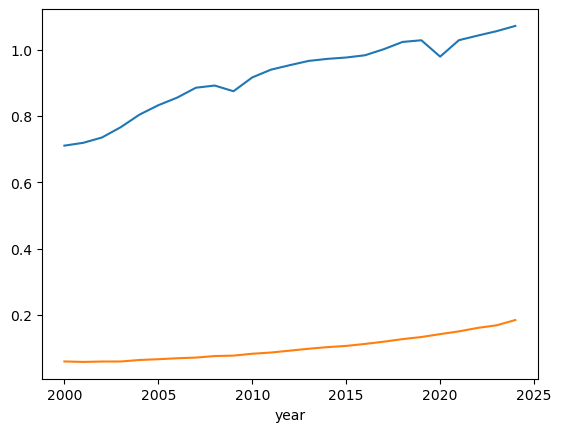

In [94]:
obs['Ef'].sel(year = slice(2000, None)).plot()
obs['Eg'].sel(year = slice(2000, None)).plot()

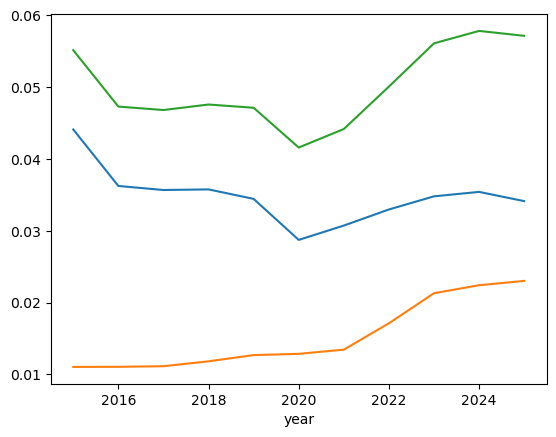

In [124]:
obs['If'].plot()
obs['Ig'].plot()
(obs['Ig']+obs['If']).plot()

In [115]:
# obs_weights = {'E': 1, 'Eg_ratio': 10, 'Ig_ratio': 1}
obs_weights = {'Eg': 1, 'Ef': 1, 'Ig': 10, 'Ig': 10}

In [116]:
result = dual_annealing(lef.cost_function, bounds, args = (parnames, params_prime, year_ini, inicond, verbose, obs, obs_weights)) # public_investment, mu_scen,
print(f'AAAAAAAAAAAAAAA dual: {result.fun:5.2f}  ', result.x)
result_dict['dual'] = result

---------------------
{'growth': 0.03316917922427848, 'beta_0': -0.04047775277537957, 'r_inv': 0.42596379548589175, 'eta_f': 0.8926988584975488, 'gamma_f': 0.11639246518142113, 'eta_g': 0.41843588441063695, 'gamma_g': 0.11931766836347615}
Too short! extending up to 2025
---------------------
{'growth': 0.019481487531036644, 'beta_0': -0.45837947726249695, 'r_inv': 0.0580620655464026, 'eta_f': 0.4890111654996872, 'gamma_f': 0.612704767245621, 'eta_g': 0.7647481903433799, 'gamma_g': 0.5014159502019147}
Too short! extending up to 2025
---------------------
{'growth': 0.029393185471559773, 'beta_0': 0.03153222054243088, 'r_inv': 0.09797377123099883, 'eta_f': 0.23875570744276048, 'gamma_f': 0.5026164630999815, 'eta_g': 0.5046598881483078, 'gamma_g': 0.3913276473632109}
Too short! extending up to 2025
---------------------
{'growth': 0.010888340242992975, 'beta_0': 0.06302737817168236, 'r_inv': 0.22946892872897046, 'eta_f': 0.5981918916106224, 'gamma_f': 0.33411161682833346, 'eta_g': 0.86409

In [117]:
result.x

array([0.02151768, 0.03927091, 0.22988435, 0.3355374 , 0.38733159,
       0.82397894, 0.20065113])

In [118]:
params_ok = params_prime.copy()

In [119]:
for par, parval in zip(parnames, result.x):
    params_ok[par] = parval

In [120]:
params_ok

{'growth': 0.021517680356436118,
 'eps': 1,
 'a': 0.7061236460320618,
 'b': 0.4298143932369072,
 'gamma_f': 0.38733159170932274,
 'gamma_g': 0.20065112641589625,
 'eta_g': 0.8239789410399367,
 'eta_f': 0.33553739901119717,
 'h_g': 0.5,
 'h_f': 0.5,
 'r_inv': 0.2298843489246688,
 'beta_0': 0.03927091008371976,
 'delta_sig': 0.5,
 'delta_g': 0.01,
 'delta_f': 0.01,
 'f_heavy': 0.1,
 'r_inv_state': 0.015}

In [121]:
year_ini

2000

In [122]:
resu_x = lef.run_model(inicond = inicond, params = params_ok, n_iter = 100, verbose = False, rule = 'maxgreen', year_ini = year_ini, public_investment=public_investment, mu_state_scenario=mu_scen)

[<Figure size 640x480 with 1 Axes>,
 <Figure size 640x480 with 1 Axes>,
 <Figure size 640x480 with 1 Axes>,
 <Figure size 640x480 with 1 Axes>]

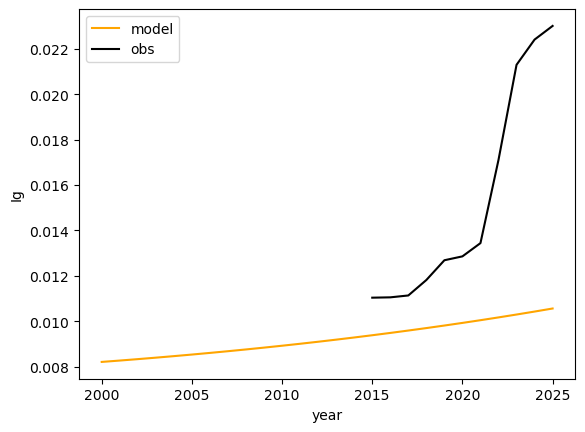

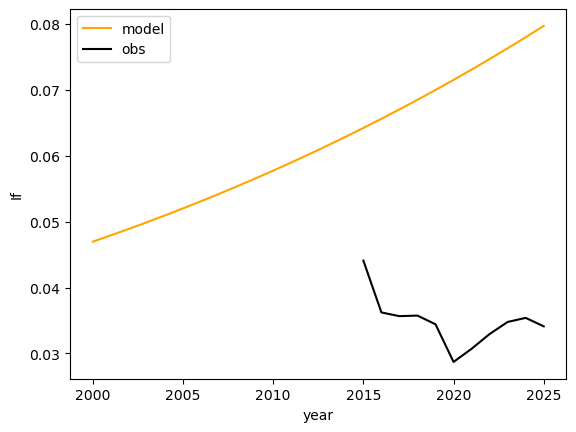

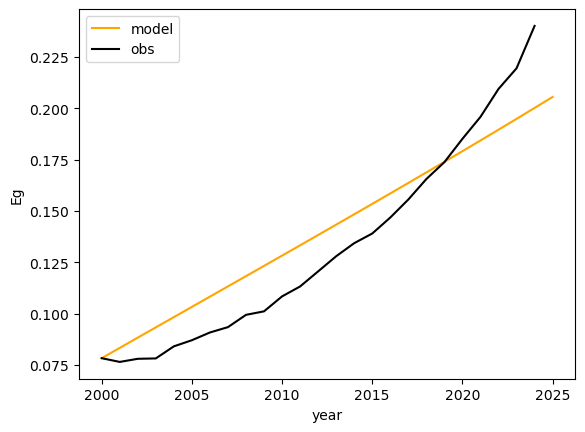

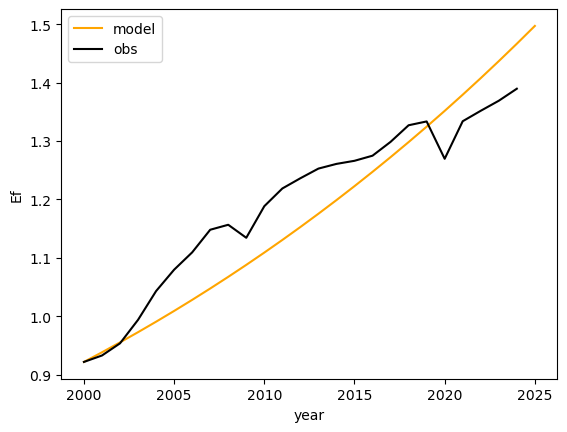

In [123]:
lef.plot_resuvsobs_ds(resu_x, obs)

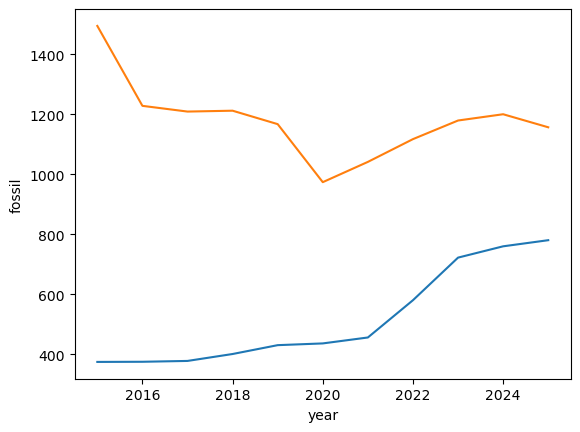

In [5]:
lef.Ig_obs.plot()
lef.If_obs.plot()

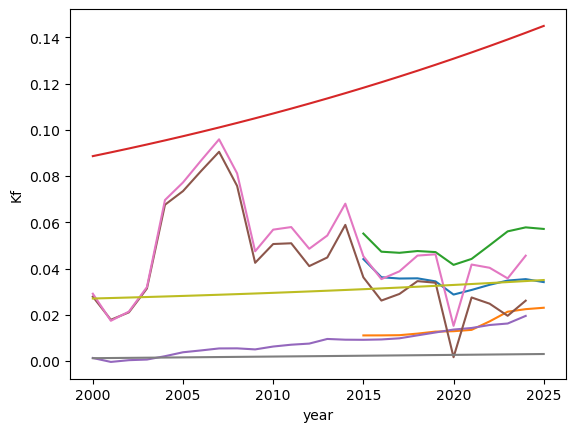

In [158]:
obs['If'].plot()
obs['Ig'].plot()
(obs['Ig']+obs['If']).plot()

((resu_x['Pg']+resu_x['Pf'])*params_prime['r_inv']).plot()


Ig_reconstr = 1/params_ok['a']*obs['Eg'].sel(year = slice(1999, None)).rolling(year = 4, min_periods = 1).mean().diff('year')
If_reconstr =  1/params_ok['b']*obs['Ef'].sel(year = slice(1999, None)).rolling(year = 5, min_periods = 1).mean().diff('year')

Ig_reconstr.plot()
If_reconstr.plot()
(Ig_reconstr+If_reconstr).plot()

(params_ok['delta_g']*resu_x['Kg']).plot()
(params_ok['delta_f']*resu_x['Kf']).plot()

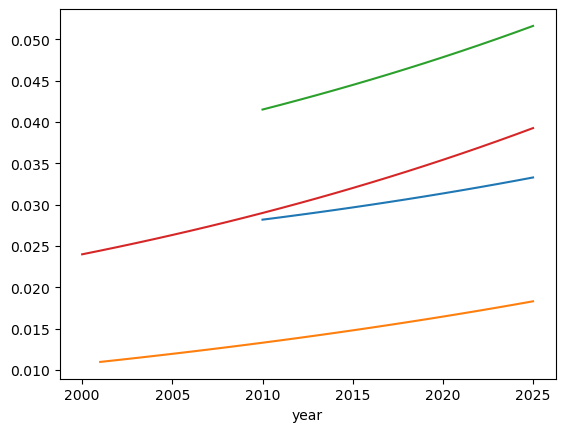

In [165]:
replacement = params_ok['delta_g']*(resu_x['Kg'] + resu_x['Kf']).shift(year = 10)
energy_growth = 0.5*params_ok['eps'] * resu_x['Y'].diff('year')

replacement.plot()
energy_growth.plot()
(replacement + energy_growth).plot()

(params['r_inv']*(resu_x['Pf']+resu_x['Pg'])).plot()

In [148]:
allobs = lef.define_obs(None)

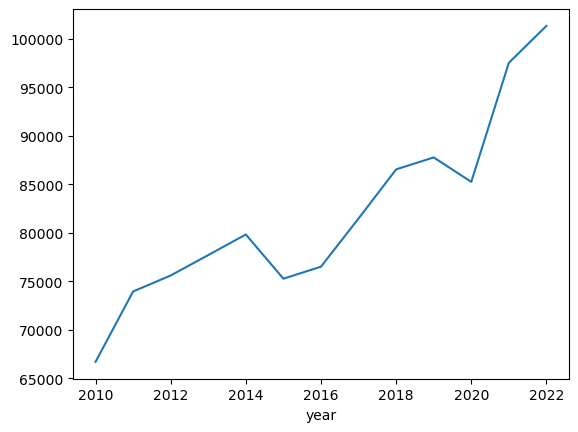

In [153]:
lef.gdp.sel(year = slice(2010, 2030)).plot()

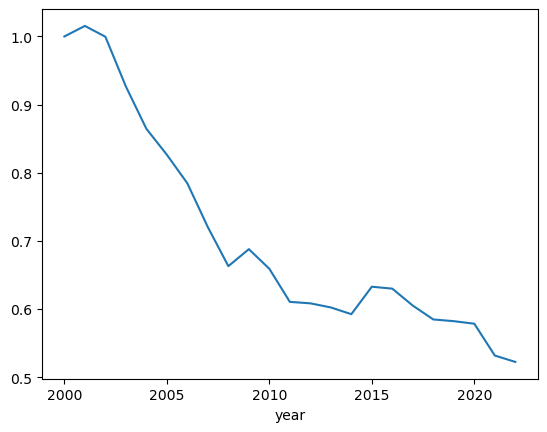

In [150]:
(allobs['E']/allobs['Y']).sel(year = slice(2000, None)).plot()

In [ ]:
obs['Eg'].rolling( )

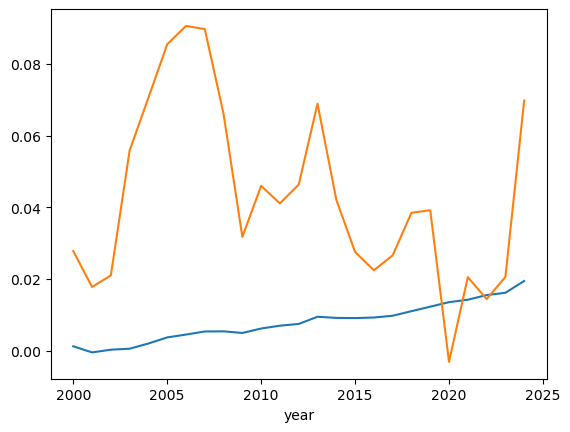

In [141]:
# obs['Eg'].sel(year = slice(1999, None)).diff('year').plot()
# obs['Ef'].sel(year = slice(1999, None)).diff('year').plot()

(1/params_ok['a']*obs['Eg'].sel(year = slice(1999, None)).rolling(year = 4, min_periods = 1).mean().diff('year')).plot()
(1/params_ok['b']*obs['Ef'].sel(year = slice(1999, None)).rolling(year = 4, min_periods = 1).mean().diff('year')).plot()

In [ ]:
year = 2000
a = 2.5
b = 1.2

E0 = lef.primary_energy.sel(year = 2000)
Y0 = lef.gdp.sel(year = 2000)
Eg0 = lef.primary_energy_decomp.green.sel(year = 2000)
Ef0 = lef.primary_energy_decomp.fossil.sel(year = 2000)

Kg0 = lef.define_K_from_E(Eg0, a, capacity_util = 1)




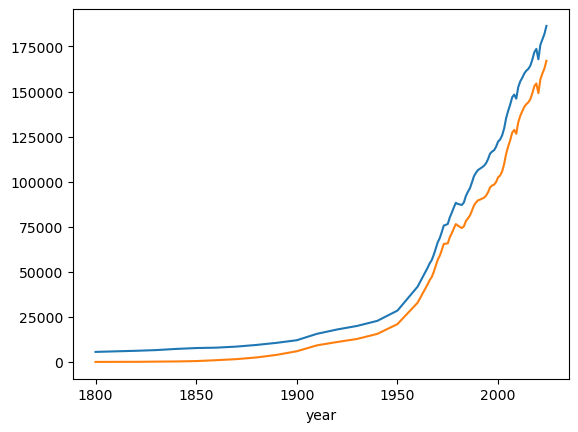

In [127]:
lef.primary_energy_decomp.total.plot()
(lef.primary_energy_decomp.green+lef.primary_energy_decomp.fossil).plot()

In [74]:
Kf0

<xarray.DataArray 'fossil' ()>
array(98403.396875)
Coordinates:
    year     int64 2000

In [73]:
Kg0

<xarray.DataArray 'green' ()>
array(3207.98351716)
Coordinates:
    year     int64 2000

In [103]:
params

params['a'] = 2.5
params['b'] = 1.2

In [131]:
obs = lef.define_obs()

In [135]:
for cos in obs:
    print(cos)

Ig_ratio
Eg_ratio
E


In [ ]:
params_prime = params.copy()
params_prime['a'] = lef.a_prime(2000, params['a'])
params_prime['b'] = lef.a_prime(2000, params['b'])

In [109]:
params_prime

{'growth': 0.01,
 'eps': 1,
 'a': 0.7675257022087629,
 'b': 0.36841233706020615,
 'gamma_f': 0.5,
 'gamma_g': 0.5,
 'eta_g': 0.2,
 'eta_f': 0.2,
 'h_g': 0.5,
 'h_f': 0.5,
 'r_inv': 0.1,
 'beta_0': 0.2,
 'delta_sig': 0.5,
 'delta_g': 0.01,
 'delta_f': 0.01,
 'f_heavy': 0.1,
 'r_inv_state': 0.015}

In [ ]:
inicond = lef.inicond_yr(2000, params, adimensional = False)

In [202]:
inicond

{'Y_ini': 1.0,
 'Eg_ini': 0.07457159202756668,
 'Ef_ini': 0.9254284079724333,
 'E_ini': 1.0,
 'Kf_ini': 1.1567855099655415,
 'Kg_ini': 0.07457159202756668}

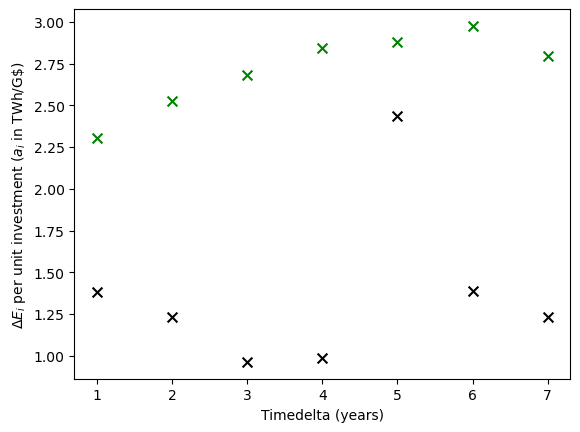

In [6]:
plt.figure()

allas = []
allbs = []

for td in range(1, 8):
    a, b = lef.estimate_a_from_investment(timedelta = td)
    plt.scatter(td, a, marker = 'x', s = 50, color = 'green')
    plt.scatter(td, b, marker = 'x', s = 50, color = 'black')
    plt.xlabel('Timedelta (years)')
    plt.ylabel(r'$\Delta E_i$ per unit investment ($a_i$ in TWh/G\$)')

    allas.append(a)
    allbs.append(b)


In [7]:
amean = np.mean(allas[:4])
bmean = np.mean(allbs[:4])
print(amean, bmean)

print(allas[0], allbs[0])

2.5908934552031946 1.141746794789906
2.3059059954696615 1.3834245450008942


In [ ]:
inicond_prime = lef.inicond_yr(2000, params_prime, adimensional = True)

102487.2197929


In [124]:
inicond_prime

{'Y_ini': array(1.),
 'Eg_ini': array(0.07825326),
 'Ef_ini': array(0.92174674),
 'E_ini': array(1.),
 'Kf_ini': 3.127429003645011,
 'Kg_ini': 0.101955227292872}

In [8]:
from importlib import reload
reload(lef)

<module 'lib_ecofun' from '/home/fedef/Research/abstractsepapers/papers/DREAM/codes/lib_ecofun.py'>

In [205]:
# Fossil
print(lef.a_prime(2010, a = 1))
print(lef.a_prime(2010, a = 2.5))

# Green
print(lef.a_prime(2010, a = 2))
print(lef.a_prime(2010, a = 3.5))

0.47108832942687057
1.1777208235671763
0.9421766588537411
1.6488091529940472


In [44]:
deltaEf, deltaEg, deltaKf, deltaKg

(<xarray.DataArray ()>
 array(158097.615625),
 <xarray.DataArray 'green' ()>
 array(8669.3418),
 <xarray.DataArray 'fossil' ()>
 array(9441.8),
 <xarray.DataArray 'green' ()>
 array(3427.9))

In [61]:
from importlib import reload
reload(lef)

<module 'lib_ecofun' from '/home/fedef/Research/abstractsepapers/papers/DREAM/codes/lib_ecofun.py'>

In [29]:
def gamma_prime(year, gamma = 0.3):
    """
    gamma is in $/kWh, gamma' is adimensional
    """
    E0 = lef.primary_energy.sel(year = year)*1e9*lef.thermal_efficiency_factor
    Y0 = lef.gdp.sel(year = year)*1e9

    return gamma*E0.data/Y0.data

In [28]:
gamma_prime(2000, 0.1), gamma_prime(2000, 0.5)

(0.13028879646925562, 0.6514439823462781)

In [6]:
lef.primary_energy.sel(year = 2000)

<xarray.DataArray 'energy' ()>
array(110416.398)
Coordinates:
    year     float64 2e+03

In [7]:
gdp = lef.get_wb_gdp_data()
gdp.sel(year = 2000)

<xarray.DataArray ()>
array(33898.96936412)
Coordinates:
    year     int64 2000